In [1]:
import sys
!{sys.executable} -m pip install shap


You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import sys 
!{sys.executable} -m pip install xgboost

You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
import sys
!{sys.executable} -m pip install --upgrade shap

You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


C:\Users\hp\AppData\Local\Temp\ipykernel_19128\3937315613.py:13: UserWarning: [15:45:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  model_obj = pickle.load(f)


Model: XGBoost
Total features: 3217  |  X_test shape: (3576, 3217)


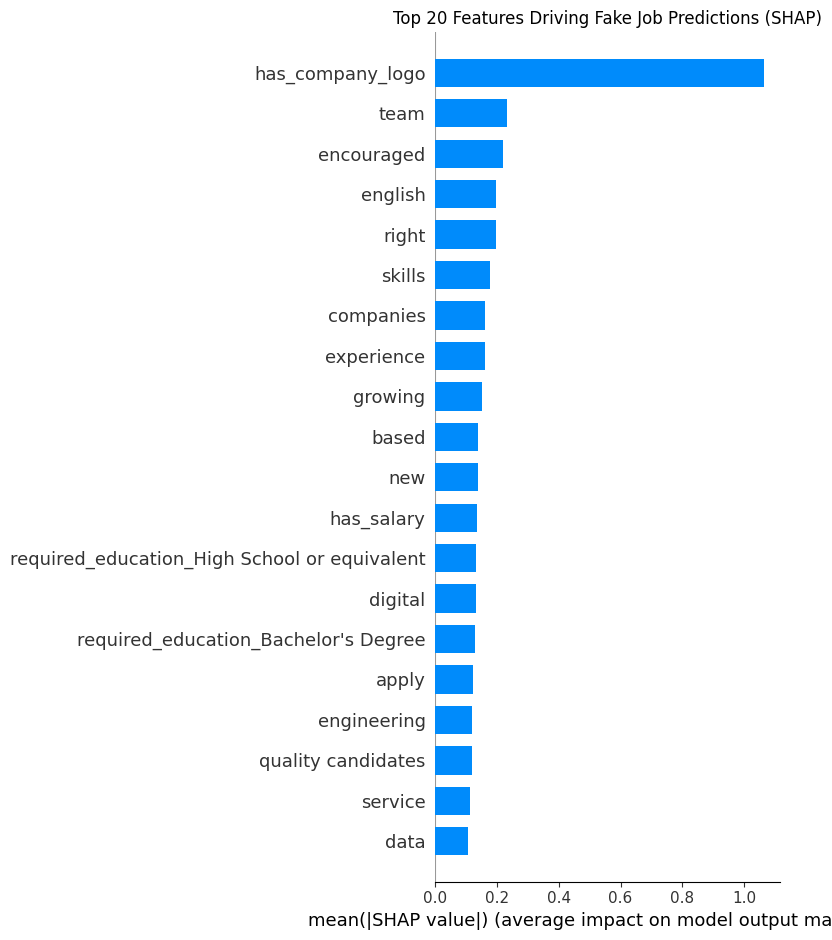

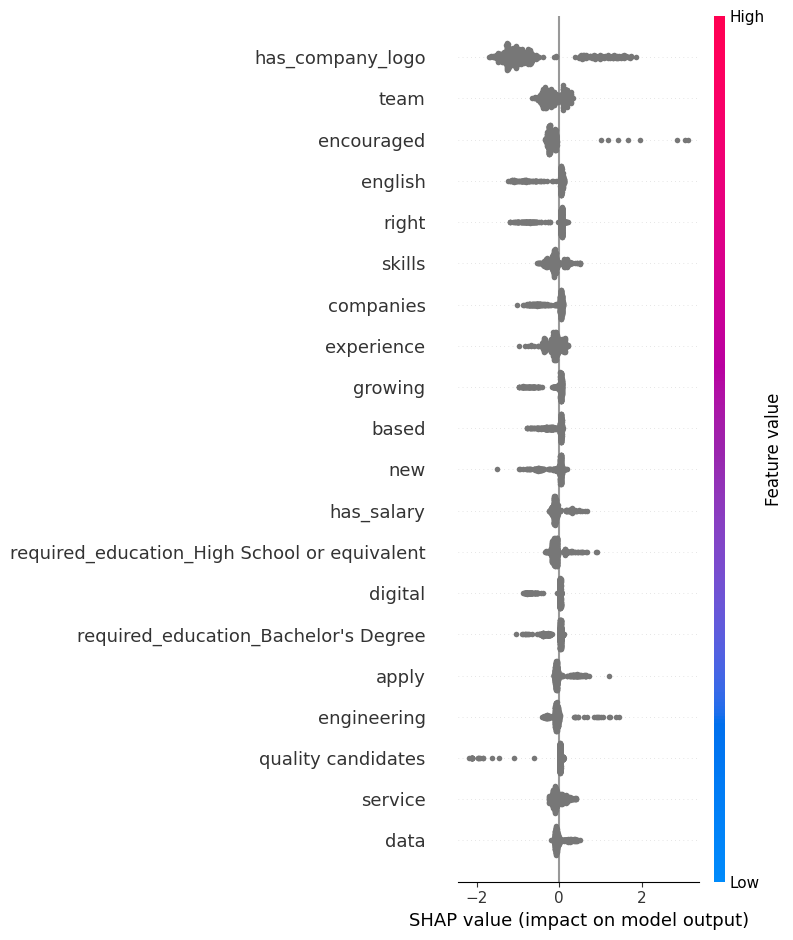

In [4]:
# ============================================
# SECTION 1: SHAP Setup + Global Feature Importance
# ============================================

import pickle
import numpy as np
import shap
import shap.explainers._tree as shap_tree
import matplotlib.pyplot as plt

# ---- Load saved artifacts (root-level paths, since files aren't in data/processed or models/) ----
with open('../best_model.pkl', 'rb') as f:
    model_obj = pickle.load(f)

model = model_obj['model']
all_feature_names = model_obj['feature_names']   # already saved correctly, no need to rebuild

with open('../train_test_split.pkl', 'rb') as f:
    data = pickle.load(f)

X_test, y_test = data['X_test'], data['y_test']

print(f"Model: {model_obj['model_name']}")
print(f"Total features: {len(all_feature_names)}  |  X_test shape: {X_test.shape}")
assert len(all_feature_names) == X_test.shape[1], "Mismatch — check!"

# ---- FIX: xgboost 3.x serializes base_score inside its raw ubjson model dump
# as a bracketed string like '[5E-1]' (meant for multi-output models). SHAP
# 0.49.1's XGBoost loader calls float() on this directly and crashes. We patch
# the ubjson decode step so base_score is cleaned right after decoding,
# before SHAP tries to convert it to float. ----
_original_decode = shap_tree.decode_ubjson_buffer

def _patched_decode(fd):
    jmodel = _original_decode(fd)
    try:
        param = jmodel["learner"]["learner_model_param"]
        bs = param["base_score"]
        if isinstance(bs, str) and bs.strip().startswith("["):
            param["base_score"] = str(float(bs.strip("[]")))
    except (KeyError, TypeError):
        pass
    return jmodel

shap_tree.decode_ubjson_buffer = _patched_decode

# ---- SHAP TreeExplainer ----
explainer = shap.TreeExplainer(model)

sample_idx = np.random.RandomState(42).choice(X_test.shape[0], size=500, replace=False)
X_sample = X_test[sample_idx]

shap_values = explainer.shap_values(X_sample)

# ---- Global feature importance ----
shap.summary_plot(shap_values, X_sample, feature_names=all_feature_names,
                   plot_type="bar", max_display=20, show=False)
plt.title("Top 20 Features Driving Fake Job Predictions (SHAP)")
plt.tight_layout()
plt.savefig('../reports/shap_global_importance.png', dpi=150)
plt.show()

shap.summary_plot(shap_values, X_sample, feature_names=all_feature_names,
                   max_display=20, show=False)
plt.tight_layout()
plt.savefig('../reports/shap_summary_beeswarm.png', dpi=150)
plt.show()


Test index: 346
True label: FAKE
Predicted:  FAKE  (probability fake = 0.999)


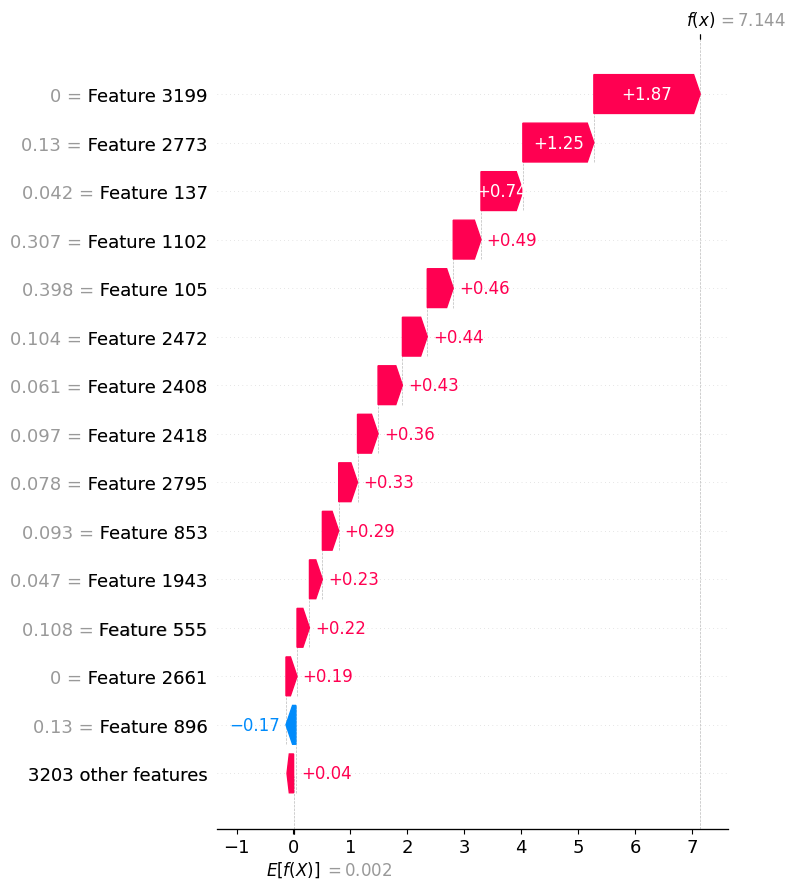


Top 10 features driving this prediction:
  has_company_logo                SHAP=+1.8681  → pushes toward FAKE
  type                            SHAP=+1.2470  → pushes toward FAKE
  apply                           SHAP=+0.7354  → pushes toward FAKE
  free                            SHAP=+0.4874  → pushes toward FAKE
  amp                             SHAP=+0.4562  → pushes toward FAKE
  skills                          SHAP=+0.4366  → pushes toward FAKE
  send                            SHAP=+0.4275  → pushes toward FAKE
  service                         SHAP=+0.3611  → pushes toward FAKE
  urgent                          SHAP=+0.3305  → pushes toward FAKE
  email                           SHAP=+0.2866  → pushes toward FAKE


In [5]:
# ============================================
# SECTION 2: Local Explanation (single job posting)
# ============================================

# ---- Pick a job posting from the test set to explain ----
# Try to find one that was correctly predicted as FAKE (label=1) for a meaningful example
fake_indices = np.where(y_test == 1)[0]
sample_i = fake_indices[15]   # first actual fraud case in test set; change index to explore others

x_single = X_test[sample_i]
true_label = y_test[sample_i]
pred_proba = model.predict_proba(x_single)[0, 1]
pred_label = model.predict(x_single)[0]

print(f"Test index: {sample_i}")
print(f"True label: {'FAKE' if true_label == 1 else 'GENUINE'}")
print(f"Predicted:  {'FAKE' if pred_label == 1 else 'GENUINE'}  (probability fake = {pred_proba:.3f})")

# ---- SHAP explanation for this single instance ----
single_shap_values = explainer(x_single)

# Waterfall plot — shows how each feature pushed the prediction up/down from baseline
shap.plots.waterfall(single_shap_values[0], max_display=15, show=False)
plt.tight_layout()
plt.savefig(f'../reports/shap_waterfall_sample_{sample_i}.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Print top contributing features in plain text (for Job Trust Score reasoning) ----
shap_vals_flat = single_shap_values[0].values
top_idx = np.argsort(np.abs(shap_vals_flat))[::-1][:10]

print("\nTop 10 features driving this prediction:")
for idx in top_idx:
    direction = "→ pushes toward FAKE" if shap_vals_flat[idx] > 0 else "→ pushes toward GENUINE"
    print(f"  {all_feature_names[idx]:30s}  SHAP={shap_vals_flat[idx]:+.4f}  {direction}")

In [ ]:
# ============================================
# SECTION 3: Suspicious Phrase Highlighting
# ============================================

import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML

# ---- Load tfidf + onehot encoder objects (needed for word-level mapping) ----
with open('../tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('../onehot_encoder.pkl', 'rb') as f:
    ohe = pickle.load(f)
    
    
    
# ---- Reload raw data + replicate exact cleaning from 02_Data_Preprocessing ----
df = pd.read_csv("../data/raw/fake_job_postings.csv", engine="python", on_bad_lines="skip")

df["has_salary"] = df["salary_range"].notnull().astype(int)
df["has_department"] = df["department"].notnull().astype(int)
df = df.drop(columns=["salary_range", "department"])

categorical_impute_cols = ["required_experience", "required_education",
                            "function", "employment_type", "industry"]
for col in categorical_impute_cols:
    df[col] = df[col].fillna("Not Specified")

text_impute_cols = ["company_profile", "benefits", "requirements", "title", "description"]
for col in text_impute_cols:
    df[col] = df[col].fillna("")
df["location"] = df["location"].fillna("Unknown")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for col in ["title", "company_profile", "description", "requirements", "benefits"]:
    df[col + "_clean"] = df[col].apply(clean_text)

# ---- Recreate the SUSPICIOUS_PHRASES flag columns (was missing -- needed by Section 5/6) ----
SUSPICIOUS_PHRASES = [
    "registration fee", "no experience required", "immediate joining",
    "no interview", "limited seats", "earn money fast", "work from home",
    "quick money", "easy money", "wire transfer", "processing fee"
]

raw_combined_lower = (df["title"] + " " + df["description"] + " " + df["requirements"]).str.lower()
for phrase in SUSPICIOUS_PHRASES:
    col_name = "flag_" + re.sub(r"\W+", "_", phrase)
    df[col_name] = raw_combined_lower.str.contains(phrase, regex=False).astype(int)

# ---- Recover the EXACT same train/test split (by index) used originally ----
y_full = df["fraudulent"].values
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42, stratify=y_full
)

# sanity check: y_test we already have from train_test_split.pkl should match this
assert (y_full[test_idx] == y_test).all(), "Index recovery mismatch — split params differ!"
print("Index recovery verified ✅")

# ---- Highlighting function for a given test-set sample ----
def highlight_job_posting(sample_i, top_n=15):
    orig_idx = test_idx[sample_i]
    row = df.iloc[orig_idx]

    single_shap_values = explainer(X_test[sample_i])
    shap_vals_flat = single_shap_values[0].values

    # Map TF-IDF feature words -> their SHAP value
    
    word_shap = {}
    for idx, fname in enumerate(all_feature_names):
        if fname in tfidf.vocabulary_:
            word_shap[fname] = shap_vals_flat[idx]

    # Highlight words in the ORIGINAL (uncleaned) description
    desc_words = row["description"].split()
    highlighted = []
    for w in desc_words:
        w_clean = re.sub(r"[^\w\s]", "", w.lower())
        if w_clean in word_shap:
            val = word_shap[w_clean]
            if val > 0.01:
                color = f"background-color: rgba(255,0,0,{min(abs(val)*2,0.8):.2f})"
                highlighted.append(f'<span style="{color}" title="SHAP={val:+.3f}">{w}</span>')
            elif val < -0.01:
                color = f"background-color: rgba(0,150,255,{min(abs(val)*2,0.8):.2f})"
                highlighted.append(f'<span style="{color}" title="SHAP={val:+.3f}">{w}</span>')
            else:
                highlighted.append(w)
        else:
            highlighted.append(w)

    html_out = " ".join(highlighted)

    print(f"Title: {row['title']}")
    print(f"True label: {'FAKE' if row['fraudulent']==1 else 'GENUINE'}  |  "
          f"Predicted proba (fake): {model.predict_proba(X_test[sample_i])[0,1]:.3f}")
    print(f"\nActive suspicious-phrase flags:")
    flag_cols_present = [c for c in df.columns if c.startswith("flag_") and row[c] == 1]
    print("  ", flag_cols_present if flag_cols_present else "None")
    print("\nRed = pushes toward FAKE | Blue = pushes toward GENUINE\n")
    display(HTML(f"<div style='line-height:1.8; font-size:14px;'>{html_out}</div>"))

# ---- Try it on the same sample from Section 2 ----
highlight_job_posting(fake_indices[15])

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator One

Index recovery verified ✅
Title: Cruise Staff Wanted *URGENT*
True label: FAKE  |  Predicted proba (fake): 0.999

Active suspicious-phrase flags:
   None

Red = pushes toward FAKE | Blue = pushes toward GENUINE



## Section 4: Job Trust Score

Converts SHAP explanations into a 0-100 trust score and human-readable reasons.

In [7]:
# ============================================
# SECTION 4: Job Trust Score
# ============================================

def compute_trust_score(fake_probability):
    """Convert model's fake-probability into a 0-100 trust score (100 = most trustworthy)."""
    trust_score = round((1 - fake_probability) * 100, 1)
    if trust_score >= 70:
        risk_level = "Low Risk"
    elif trust_score >= 40:
        risk_level = "Medium Risk"
    else:
        risk_level = "High Risk"
    return trust_score, risk_level

def get_top_reasons(shap_vals_flat, feature_names, top_n=5, direction="fake"):
    """Return top_n human-readable reasons pushing toward 'fake' or 'genuine'."""
    if direction == "fake":
        idx = np.where(shap_vals_flat > 0)[0]
    else:
        idx = np.where(shap_vals_flat < 0)[0]
    idx = idx[np.argsort(np.abs(shap_vals_flat[idx]))[::-1][:top_n]]
    reasons = []
    for i in idx:
        fname = feature_names[i]
        if fname.startswith("flag_"):
            label = "Contains suspicious phrase: '" + fname.replace("flag_", "").replace("_", " ") + "'"
        elif fname.startswith(("employment_type_", "required_experience_", "required_education_", "industry_", "function_")):
            label = "Category: " + fname.replace("_", " ")
        else:
            label = "Suspicious wording: '" + fname + "'" if direction == "fake" else "Reassuring wording: '" + fname + "'"
        reasons.append(label)
    return reasons

# ---- Demo on the same sample from Section 2/3 ----
demo_i = fake_indices[15]
demo_shap = explainer(X_test[demo_i])
demo_vals = demo_shap[0].values
demo_proba = model.predict_proba(X_test[demo_i])[0, 1]

trust_score, risk_level = compute_trust_score(demo_proba)
top_fake_reasons = get_top_reasons(demo_vals, all_feature_names, top_n=5, direction="fake")

print(f"Job Trust Score: {trust_score}/100  ->  {risk_level}")
print(f"Model confidence this is fake: {demo_proba*100:.1f}%\n")
print("Top reasons for this score:")
for r in top_fake_reasons:
    print("  -", r)


Job Trust Score: 0.10000000149011612/100  ->  High Risk
Model confidence this is fake: 99.9%

Top reasons for this score:
  - Suspicious wording: 'has_company_logo'
  - Suspicious wording: 'type'
  - Suspicious wording: 'apply'
  - Suspicious wording: 'free'
  - Suspicious wording: 'amp'


## Section 5: Reusable Prediction Function

Wraps the full pipeline so any new job posting (typed, pasted, or scraped) can be checked in one call.

In [11]:
# ============================================
# SECTION 5: Reusable predict_and_explain() Function
# ============================================
# This wraps the ENTIRE pipeline (cleaning -> flags -> TF-IDF -> OneHot -> predict -> SHAP -> trust score)
# so any new job posting (typed, pasted, or scraped) can be checked with one function call.

from scipy.sparse import hstack, csr_matrix

CATEGORICAL_COLS = ["employment_type", "required_experience", "required_education", "industry", "function"]

DEFAULT_JOB_FIELDS = {
    "title": "", "company_profile": "", "description": "", "requirements": "", "benefits": "",
    "employment_type": "Not Specified", "required_experience": "Not Specified",
    "required_education": "Not Specified", "industry": "Not Specified", "function": "Not Specified",
    "telecommuting": 0, "has_company_logo": 0, "has_questions": 0,
    "has_salary": 0, "has_department": 0,
}

def _build_feature_vector(job):
    """job: dict with any subset of DEFAULT_JOB_FIELDS keys. Missing keys use defaults."""
    job = {**DEFAULT_JOB_FIELDS, **job}

    title_clean = clean_text(job["title"])
    cp_clean = clean_text(job["company_profile"])
    desc_clean = clean_text(job["description"])
    req_clean = clean_text(job["requirements"])
    ben_clean = clean_text(job["benefits"])
    full_text = f"{title_clean} {cp_clean} {desc_clean} {req_clean} {ben_clean}"

    raw_combined_lower = f"{job['title']} {job['description']} {job['requirements']}".lower()
    flag_vals = [int(phrase in raw_combined_lower) for phrase in SUSPICIOUS_PHRASES]
    suspicious_count = sum(flag_vals)
    desc_len = len(desc_clean.split())
    has_gmail = int("gmail.com" in job["description"].lower())

    X_text = tfidf.transform([full_text])
    X_cat = ohe.transform([[job[c] for c in CATEGORICAL_COLS]])

    numeric_vals = [job["telecommuting"], job["has_company_logo"], job["has_questions"],
                     job["has_salary"], job["has_department"], suspicious_count, desc_len, has_gmail] + flag_vals
    X_numeric = csr_matrix(np.array(numeric_vals, dtype=float).reshape(1, -1))

    X_new = hstack([X_text, X_cat, X_numeric]).tocsr()
    assert X_new.shape[1] == len(all_feature_names), "Feature dimension mismatch!"
    return X_new, job, full_text

def predict_and_explain(job, top_n=6):
    """
    job: dict, e.g. {"title": "...", "description": "...", "requirements": "...",
                      "employment_type": "Full-time", ...}  (any missing field defaults sensibly)
    Returns a dict with prediction, trust score, risk level, and explainable reasons.
    """
    X_new, job_full, full_text = _build_feature_vector(job)

    proba_fake = float(model.predict_proba(X_new)[0, 1])
    prediction = "FAKE" if proba_fake >= 0.5 else "GENUINE"
    trust_score, risk_level = compute_trust_score(proba_fake)

    sv = explainer(X_new)
    vals = sv[0].values

    top_fake_reasons = get_top_reasons(vals, all_feature_names, top_n=top_n, direction="fake")
    top_genuine_reasons = get_top_reasons(vals, all_feature_names, top_n=top_n, direction="genuine")

    active_flags = [SUSPICIOUS_PHRASES[i] for i, v in enumerate(
        [int(p in f"{job_full['title']} {job_full['description']} {job_full['requirements']}".lower())
         for p in SUSPICIOUS_PHRASES]) if v == 1]

    return {
        "prediction": prediction,
        "fake_probability": round(proba_fake, 4),
        "trust_score": trust_score,
        "risk_level": risk_level,
        "top_fake_reasons": top_fake_reasons,
        "top_genuine_reasons": top_genuine_reasons,
        "active_suspicious_phrases": active_flags,
        "shap_values": vals,
        "X_vector": X_new,
    }

def print_report(result):
    print(f"Prediction: {result['prediction']}  (fake probability: {result['fake_probability']*100:.1f}%)")
    print(f"Job Trust Score: {result['trust_score']}/100  ->  {result['risk_level']}\n")
    if result["top_fake_reasons"]:
        print("Reasons this looks suspicious:")
        for r in result["top_fake_reasons"]:
            print("  -", r)
    if result["top_genuine_reasons"]:
        print("\nReasons this looks legitimate:")
        for r in result["top_genuine_reasons"]:
            print("  -", r)
    if result["active_suspicious_phrases"]:
        print("\nMatched suspicious phrases:", result["active_suspicious_phrases"])

# ---- Quick test ----
test_job = {
    "title": "URGENT Cruise Staff Wanted",
    "description": "Earn money fast! No experience required. Send registration fee to secure your spot.",
    "requirements": "No interview needed.",
}
result = predict_and_explain(test_job)
print_report(result)


Prediction: FAKE  (fake probability: 96.9%)
Job Trust Score: 3.1/100  ->  High Risk

Reasons this looks suspicious:
  - Suspicious wording: 'earn'
  - Suspicious wording: 'has_company_logo'
  - Suspicious wording: 'money'
  - Suspicious wording: 'urgent'
  - Suspicious wording: 'experience required'
  - Suspicious wording: 'send'

Reasons this looks legitimate:
  - Reassuring wording: 'description_length'
  - Reassuring wording: 'amp'
  - Reassuring wording: 'secure'
  - Reassuring wording: 'data entry'
  - Reassuring wording: 'service'
  - Reassuring wording: 'has_salary'

Matched suspicious phrases: ['registration fee', 'no experience required', 'no interview', 'earn money fast']


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


## Section 6: Check a Job Posting from a URL

**Note:** Simple scraping works on static company career pages. JS-heavy sites (LinkedIn, Naukri, Indeed) often block or hide content from basic scraping — use `check_job_text()` to paste the posting manually in that case.

In [12]:
import sys
!{sys.executable} -m pip install requests beautifulsoup4


You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [13]:
# ============================================
# SECTION 6: Check a Job Posting from a URL
# ============================================
import requests
from bs4 import BeautifulSoup

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0 Safari/537.36"}

def scrape_job_posting(url, timeout=10):
    """
    Best-effort scraper for job posting pages. Works well on simple/static company
    career pages. JS-heavy sites (LinkedIn, many aggregator sites) often won't render
    full content via plain requests -- if scraped text looks too short, fall back to
    manual paste using check_job_text() below.
    """
    resp = requests.get(url, headers=HEADERS, timeout=timeout)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")

    # Remove non-content elements
    for tag in soup(["script", "style", "nav", "footer", "header", "noscript"]):
        tag.decompose()

    # Title: prefer <h1>, fallback to <title>
    h1 = soup.find("h1")
    title = h1.get_text(strip=True) if h1 else (soup.title.get_text(strip=True) if soup.title else "")

    # Description: use the largest text block on the page (common heuristic for main content)
    candidates = soup.find_all(["p", "div", "li"])
    best_block, best_len = "", 0
    for c in candidates:
        text = c.get_text(separator=" ", strip=True)
        if len(text) > best_len:
            best_block, best_len = text, len(text)

    # Fallback: all visible body text if the heuristic block is too short
    body_text = soup.get_text(separator=" ", strip=True)
    description = best_block if best_len > 200 else body_text

    return {
        "title": title,
        "description": description,
        "requirements": "",   # generic pages rarely separate this cleanly
        "raw_word_count": len(description.split()),
    }

def check_job_url(url):
    print(f"Fetching: {url}\n")
    try:
        scraped = scrape_job_posting(url)
    except Exception as e:
        print(f"Could not fetch/parse this URL ({e}).")
        print("This usually means the site needs JavaScript or blocks scraping (common for LinkedIn/Naukri/Indeed).")
        print("Use check_job_text(title=..., description=...) instead and paste the posting manually.")
        return None

    if scraped["raw_word_count"] < 40:
        print("Warning: very little text was extracted -- this page likely needs JavaScript to render.")
        print("Falling back won't be reliable. Please use check_job_text() and paste the posting manually.\n")

    print(f"Extracted title: {scraped['title']}")
    print(f"Extracted text length: {scraped['raw_word_count']} words\n")

    job = {"title": scraped["title"], "description": scraped["description"], "requirements": scraped["requirements"]}
    result = predict_and_explain(job)
    print_report(result)
    return result

def check_job_text(title="", description="", requirements="", **extra_fields):
    """Manual fallback: paste job title/description/requirements directly."""
    job = {"title": title, "description": description, "requirements": requirements, **extra_fields}
    result = predict_and_explain(job)
    print_report(result)
    return result

# ---- Example usage ----
check_job_url("https://www.amazon.jobs/en-gb/jobs/10454435/software-dev-engineer-i-amazon-university-talent-acquisition")
# check_job_text(title="Data Entry - Work From Home", description="Earn $500/day! No experience needed, just send your bank details to get started.")


Fetching: https://www.amazon.jobs/en-gb/jobs/10454435/software-dev-engineer-i-amazon-university-talent-acquisition

Extracted title: Software Dev Engineer I, Amazon University Talent Acquisition
Extracted text length: 553 words

Prediction: GENUINE  (fake probability: 2.5%)
Job Trust Score: 97.5/100  ->  Low Risk

Reasons this looks suspicious:
  - Suspicious wording: 'has_company_logo'
  - Suspicious wording: 'apply'
  - Suspicious wording: 'hiring'
  - Suspicious wording: 'note'
  - Suspicious wording: 'including'
  - Suspicious wording: 'data'

Reasons this looks legitimate:
  - Reassuring wording: 'right'
  - Reassuring wording: 'university'
  - Reassuring wording: 'employer'
  - Reassuring wording: 'engineering'
  - Reassuring wording: 'software'
  - Reassuring wording: 'brands'


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


{'prediction': 'GENUINE',
 'fake_probability': 0.0251,
 'trust_score': 97.5,
 'risk_level': 'Low Risk',
 'top_fake_reasons': ["Suspicious wording: 'has_company_logo'",
  "Suspicious wording: 'apply'",
  "Suspicious wording: 'hiring'",
  "Suspicious wording: 'note'",
  "Suspicious wording: 'including'",
  "Suspicious wording: 'data'"],
 'top_genuine_reasons': ["Reassuring wording: 'right'",
  "Reassuring wording: 'university'",
  "Reassuring wording: 'employer'",
  "Reassuring wording: 'engineering'",
  "Reassuring wording: 'software'",
  "Reassuring wording: 'brands'"],
 'active_suspicious_phrases': [],
 'shap_values': array([-1.6305279e-05,  1.0181939e-04,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       shape=(3217,), dtype=float32),
 'X_vector': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 190 stored elements and shape (1, 3217)>}